In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rifatalam3/coffee-revenue-dataset/Coffe_sales.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/rifatalam3/coffee-revenue-dataset/Coffe_sales.csv')

# Exploring Data

In [3]:
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [4]:
df.columns

Index(['hour_of_day', 'cash_type', 'money', 'coffee_name', 'Time_of_Day',
       'Weekday', 'Month_name', 'Weekdaysort', 'Monthsort', 'Date', 'Time'],
      dtype='object')

In [5]:
print(f'Shape: {df.shape[0]} values and {df.shape[1]} columns')

Shape: 3547 values and 11 columns


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


In [7]:
df.describe()

,hour_of_day,money,Weekdaysort,Monthsort
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000


In [8]:
df.isna().sum()

hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64

Data Quality Check - no missing values detected across all columns. The dataset is complete and ready for analysis.

In [9]:
# Data Transformation 
# Convert 'Date' column to real datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Check if it workes
print(df['Date'].dtype)

datetime64[ns]


# Business Analysis

In [10]:
# What is the total revenue, total sales and average?
total_revenue = df['money'].sum()
total_sales = df['money'].count()
average_price = df['money'].mean()

# Output
print(f'The total Revenue is: $ {total_revenue:.2f}')
print(f'The total sales are: {total_sales}')
print(f'The average price is: $ {average_price:.2f}')

The total Revenue is: $ 112245.58
The total sales are: 3547
The average price is: $ 31.65


In [11]:
# Short Analyse of the performance by products
product_performance = (df.groupby('coffee_name')
                                 ['money']
                                 .agg(revenue=('sum'), total_sales=('count'), average=('mean'))
                                 .reset_index()
                                 .round(2)
                                 .sort_values(by='revenue', ascending=False))

# Output
print(product_performance)

           coffee_name   revenue  total_sales  average
7                Latte  26875.30          757    35.50
1  Americano with Milk  24751.12          809    30.59
2           Cappuccino  17439.14          486    35.88
0            Americano  14650.26          564    25.98
6        Hot Chocolate   9933.46          276    35.99
3                Cocoa   8521.16          239    35.65
4              Cortado   7384.86          287    25.73
5             Espresso   2690.28          129    20.85


*Latte* is making the most revenue while *Americano with Milk* generates the most sales.
Meanwhile *Espresso* is an underperforming product with 129 sales and a revenue of $ 2690.28, which could be a reason of the high average price, indicating a price sensetivity of customers.

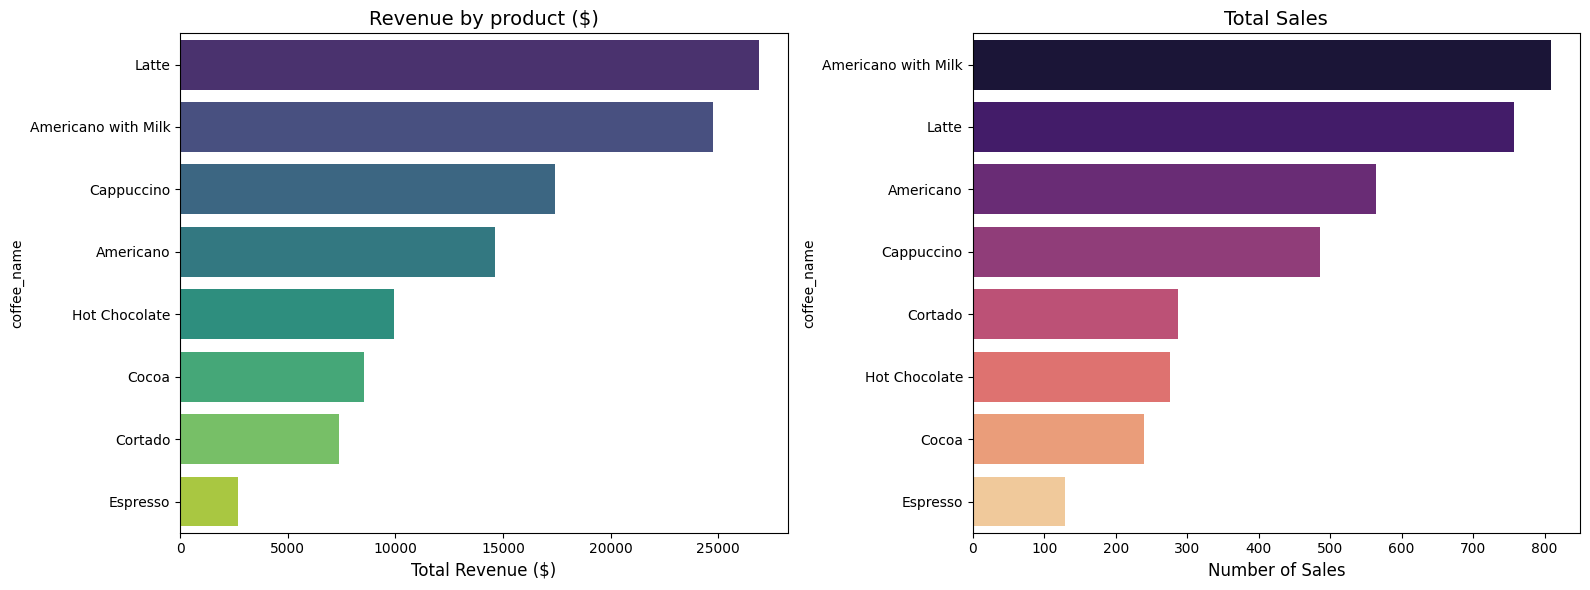

In [12]:
# Visualize the total revenue and the sales through a subplot
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,6))

sns.barplot(data = product_performance,
           x='revenue', y='coffee_name', 
           palette='viridis', hue='coffee_name', legend=False, ax=ax1)
ax1.set_title('Revenue by product ($)', fontsize=14)
ax1.set_xlabel('Total Revenue ($)', fontsize=12)

sns.barplot(data=product_performance.sort_values('total_sales', ascending=False),
           x='total_sales', y='coffee_name',
           palette='magma', hue='coffee_name', legend=False, ax=ax2)
ax2.set_title('Total Sales', fontsize=14)
ax2.set_xlabel('Number of Sales', fontsize=12)

plt.tight_layout()
plt.show()

The charts clearly show that *Latte* is making the highest revenue while *Americano with Milk* generates the most sales. Both products are the top products while *Espresso* is not making a high revenue nor a high sales product. Due to the high average price of the *Espresso* it could be recommended to check either a discount or special offer to push *Espresso*.

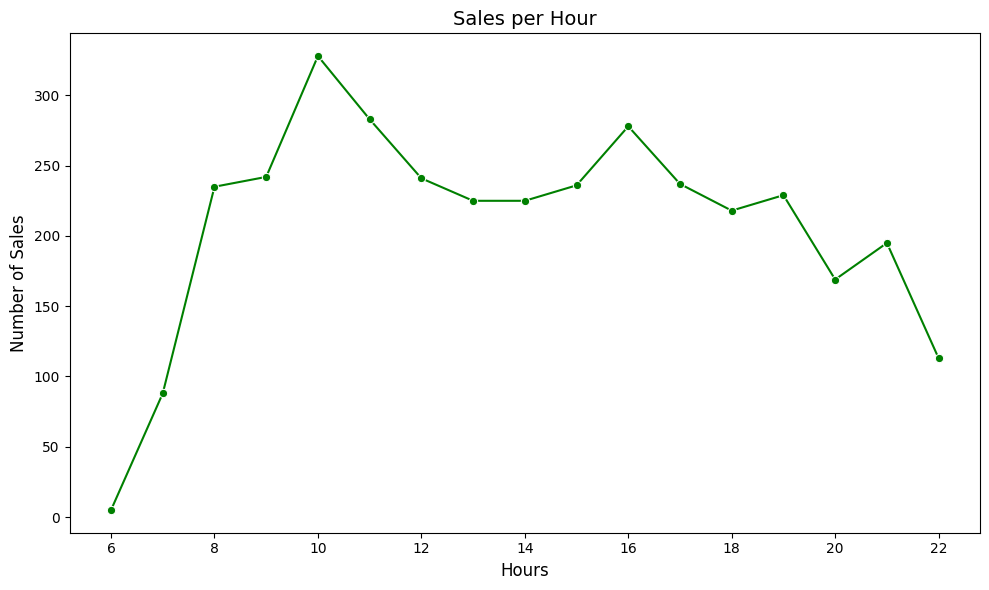

--- Quick Insights ---
Hour: 10:00 - Sales: 328
Hour: 11:00 - Sales: 283
Hour: 16:00 - Sales: 278


In [13]:
# Analysis the number of sales by hour to check for peak time 
hourly_sales = df.groupby('hour_of_day')['money'].count()

# Visualize the sales as a line chart 
plt.figure(figsize=(10,6))
sns.lineplot(x=hourly_sales.index, y=hourly_sales.values, marker='o', color='green')

plt.title('Sales per Hour', fontsize=14)
plt.xlabel('Hours', fontsize=12)
plt.ylabel('Number of Sales', fontsize=12)

plt.tight_layout()
plt.show()

peak_times = hourly_sales.sort_values(ascending=False).head(3)
print(f'--- Quick Insights ---')
for hour, sales in peak_times.items():
    print(f'Hour: {hour}:00 - Sales: {sales}')

The analysis shows that the peak time occur around 10:00am, 11:00am and also after 04:00pm, which should be taken into account when planning staff. Interestingly, there is still a high demand on coffee at 10:00 pm. In contrast to the early opening hours of 06:00 am which shows that there is not realy a high demand on coffee. It is worth considering early-bird specials or discounts to boost the sales in the early morning hours or the changing the opening hours to 07:00am to 11:00pm to generate a higher number of sales. 

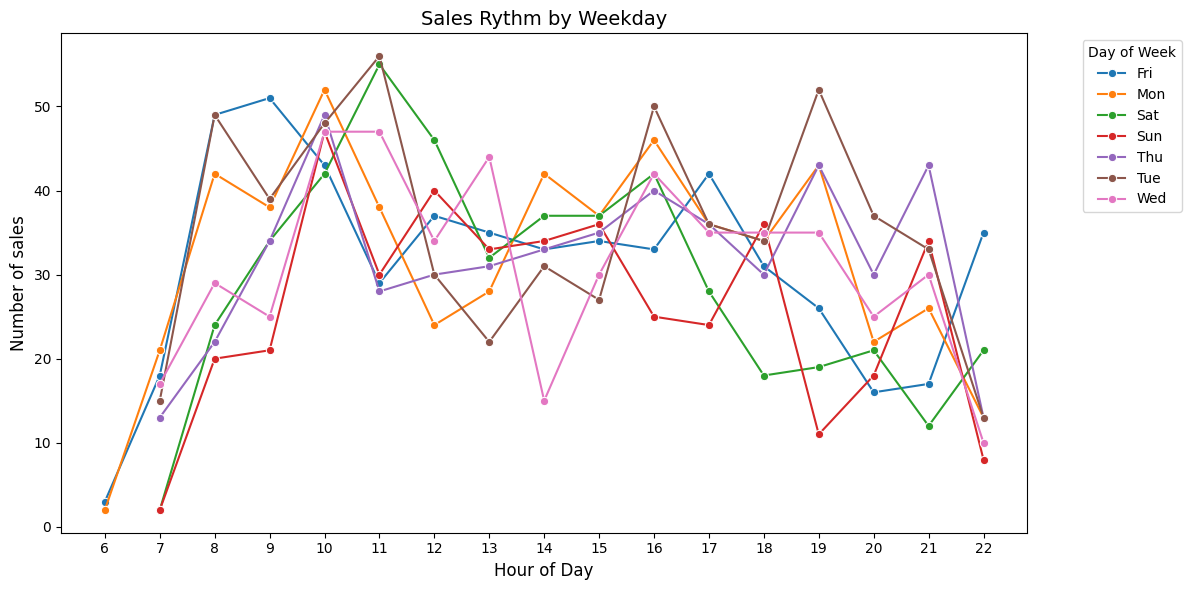

In [14]:
# Checking the late night sales 
sales_rythm = df.groupby(['hour_of_day', 'Weekday'])['money'].count().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=sales_rythm,
            x='hour_of_day',
            y='money',
            hue='Weekday',
            marker='o')
plt.title('Sales Rythm by Weekday', fontsize=14)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of sales', fontsize=12)
plt.xticks(range(6,23))
plt.legend(title='Day of Week', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

The analysis shows, that only on Friday and Saturday there is a higher demand on coffee sales after 09:00pm - and also on these both days the there are sales at 06:00am in the morning. So maybe it could consider for a longer opening time on Friday and Saturday. During the Weekdays the sales start to the normal business times at 07:00am. To boost the sales in the morning and also the weak hours during the weekdays it could help to offer some early-morning specials as well as afternoon discounts or bundles.